# Лабораторная работа №7
## *декодирование DTMF сигнала*
по курсу Цифровая обработка сигналов  
  
**направление:** Речевые технологии и машинное обучение  
**преподаватель:** Рыбин Сергей Витальевич  
**выполнили:** Иванова Мария Кирилловна  
**группа:** М4121

In [38]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from math import pi, cos

### Загрузка и воспроизведение исходного сигнала*
*Вариант сигнала DTMF_Lab5

In [66]:
def draw_waveform(y, sr=44100, title="Waveform"):

    t = np.arange(len(y)) / sr

    plt.figure(figsize=(14, 4))
    plt.plot(t, y, color="#A1B7F4")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.grid(True)
    plt.show()

Len is 211680. Sample rate is 44100
Исходная частота дискретизации: 44100


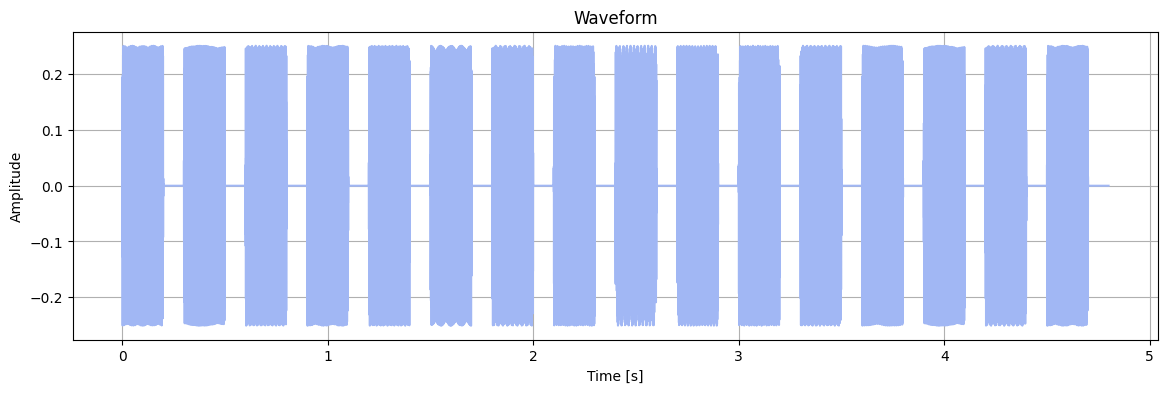

In [ ]:
signal, sr = librosa.core.load('./DTMF_Lab5.wav', sr=None)
print(f"Len is {len(signal)}. Sample rate is {sr}")
print("Исходная частота дискретизации:", sr)
player = ipd.Audio(signal, rate=sr)
ipd.display(player)
draw_waveform(signal, sr=sr)

### DTMF частоты

In [68]:
low_freqs  = [697, 770, 852, 941]
high_freqs = [1209, 1336, 1477, 1633]

dtmf_map = {
    (697,1209): '1', (697,1336): '2', (697,1477): '3', (697,1633): 'A',
    (770,1209): '4', (770,1336): '5', (770,1477): '6', (770,1633): 'B',
    (852,1209): '7', (852,1336): '8', (852,1477): '9', (852,1633): 'C',
    (941,1209): '*', (941,1336): '0', (941,1477): '#', (941,1633): 'D'
}

### Реализация Алгоритма Герцеля

In [72]:
def goertzel_power(x, freq, sr):
    N = len(x)
    k = int(round(freq * N / sr)) 
    alpha = 2 * pi * k / N
    coeff = 2 * cos(alpha)

    g_next = 0
    g_next2 = 0

    # обратная рекурсия
    for j in range(N - 1, -1, -1):
        g = x[j] + coeff * g_next - g_next2
        g_next2 = g_next
        g_next = g

    g1 = g_next
    g2 = g_next2

    # мощность
    power = (g1 * np.cos(alpha) - g2)**2 + (g1 * np.sin(alpha))**2
    return power


In [86]:
tone_len = int(0.2 * sr)   # 200 ms фрагменты
pause_len = int(0.1 * sr)   # 100 ms паузы

digits = []
i = 0

for n in range(16):
    start = i
    end = i + tone_len

    frame = signal[start:end]

    # измерение частот
    low_powers  = {f: goertzel_power(frame, f, sr) for f in low_freqs}
    high_powers = {f: goertzel_power(frame, f, sr) for f in high_freqs}

    low  = max(low_powers, key=low_powers.get)
    high = max(high_powers, key=high_powers.get)

    digit = dtmf_map[(low, high)]
    digits.append(digit)

    # следующий тон
    i = end + pause_len

print("16 тонов:\n\n", digits)

16 тонов:

 ['8', '*', '9', '#', '0', 'A', '1', 'B', '2', 'C', '3', 'D', '4', '*', '5', '#']


## Выводы
- #### Алгоритм Герцеля позволяет быстро находить известные частоты в сигнале.
- #### Для распознавания DTMF тонов достаточно выделить низкие и высокие частоты и найти максимальную мощность в каждой из групп.
- #### Для успешной работы алгоритма необходимо четко выделяить сигнал и паузы между сигналами.
- #### Метод эффективен, но чувствителен к изменениям длительности тонов и шумам, поэтому в реальных системах может потребоваться дополнительная обработка сигнала.